In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

# 1. Cargar datos
df = pd.read_csv('polymarket_pro_dataset_with_resolution.csv'
)
df['timestamp'] = pd.to_datetime(df['timestamp'])

# ORDEN CRÍTICO: Para evitar Target Leakage y calcular series temporales correctamente
df = df.sort_values(by=['market_slug', 'timestamp']).reset_index(drop=True)

# ==========================================
# 3. FEATURE ENGINEERING (Microestructura y L3)
# ==========================================

# A. Volúmenes Agregados (Top 3 Niveles)
for side in ['up', 'down']:
    # Suma de volumen de Bid y Ask en los 3 niveles
    df[f'{side}_total_bid_vol'] = df[f'{side}_bid_s_1'] + df[f'{side}_bid_s_2'] + df[f'{side}_bid_s_3']
    df[f'{side}_total_ask_vol'] = df[f'{side}_ask_s_1'] + df[f'{side}_ask_s_2'] + df[f'{side}_ask_s_3']
    
    # B. Order Book Imbalance Global (L3 OBI)
    # Rango de [-1, 1]. -1 = Presión total de venta, 1 = Presión total de compra
    df[f'{side}_obi_l3'] = (df[f'{side}_total_bid_vol'] - df[f'{side}_total_ask_vol']) / \
                           (df[f'{side}_total_bid_vol'] + df[f'{side}_total_ask_vol'] + 1e-8)
    
    # C. Weighted Mid Price (WMP) del Nivel 1
    # Pondera el precio por el volumen contrario. Más preciso que el Mid Price simple.
    df[f'{side}_wmp_1'] = (df[f'{side}_bid_p_1'] * df[f'{side}_ask_s_1'] + df[f'{side}_ask_p_1'] * df[f'{side}_bid_s_1']) / \
                          (df[f'{side}_bid_s_1'] + df[f'{side}_ask_s_1'] + 1e-8)
                          
    # Spread del Nivel 1
    df[f'{side}_spread_1'] = df[f'{side}_ask_p_1'] - df[f'{side}_bid_p_1']

# ==========================================
# 4. FEATURE ENGINEERING (Dinámica de BTC)
# ==========================================

# Asumiendo que cada fila es aprox 10 segundos:
# Span 6 = ~1 minuto; Span 18 = ~3 minutos
df['btc_ema_1m'] = df['btc_spot'].transform(lambda x: x.ewm(span=6, adjust=False).mean())
df['btc_ema_3m'] = df['btc_spot'].transform(lambda x: x.ewm(span=18, adjust=False).mean())

# D. Distancia del precio actual a la EMA (Oscilador de tendencia)
# Valores positivos indican que BTC está por encima de su tendencia reciente (Bullish momentum)
df['btc_dist_ema_1m'] = (df['btc_spot'] / df['btc_ema_1m']) - 1
df['btc_dist_ema_3m'] = (df['btc_spot'] / df['btc_ema_3m']) - 1

# Retorno porcentual suavizado (ventana de 6 periodos = 1 minuto atrás)
# Esto evita el ruido del segundo a segundo
df['btc_return_1m'] = df.groupby('market_slug')['btc_spot'].pct_change(periods=6)

# Limpieza de nulos generados por los cálculos temporales (retornos y EMAs iniciales)
df = df.dropna().reset_index(drop=True)

Entrenando XGBoost...

Accuracy: 0.5803

              precision    recall  f1-score   support

    Down (0)       0.69      0.38      0.49      1885
      Up (1)       0.53      0.80      0.64      1660

    accuracy                           0.58      3545
   macro avg       0.61      0.59      0.57      3545
weighted avg       0.62      0.58      0.56      3545



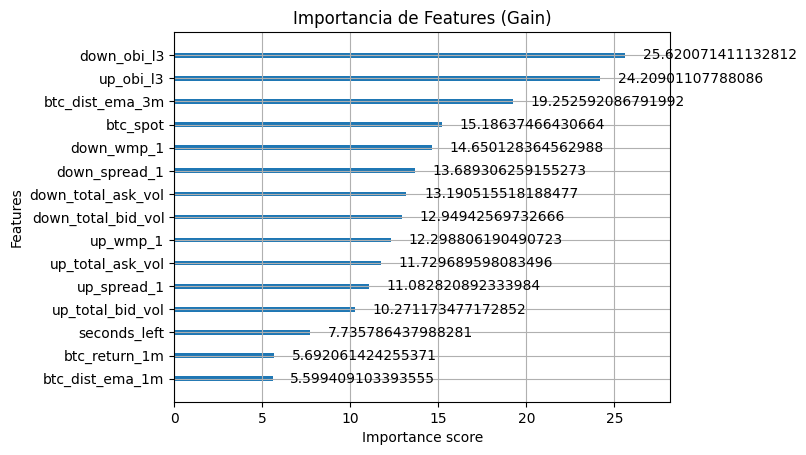

In [8]:
# ==========================================
# 5. PREPARACIÓN DEL MODELO
# ==========================================

# Variable objetivo
df['target'] = df['resolution'].map({'up': 1, 'down': 0})

# Seleccionamos las variables finales
features = [
    'seconds_left', 'btc_spot',
    'btc_dist_ema_1m', 'btc_dist_ema_3m', 'btc_return_1m',
    'up_wmp_1', 'down_wmp_1',
    'up_spread_1', 'down_spread_1',
    'up_obi_l3', 'down_obi_l3',
    'up_total_bid_vol', 'up_total_ask_vol',
    'down_total_bid_vol', 'down_total_ask_vol'
]

X = df[features]
y = df['target']

# Split temporal (Simulación de entorno real)
# En lugar de un split aleatorio, cogemos el primer 80% del tiempo para entrenar 
# y el último 20% para validar. Esto previene completamente el target leakage temporal.
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# ==========================================
# 6. ENTRENAMIENTO XGBOOST
# ==========================================

model = xgb.XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8, # Ayuda a prevenir sobreajuste
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

print("Entrenando XGBoost...")
model.fit(X_train, y_train)

# Evaluación
y_pred = model.predict(X_test)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=['Down (0)', 'Up (1)']))

# Importancia de variables
xgb.plot_importance(model, importance_type='gain', max_num_features=15)
plt.title("Importancia de Features (Gain)")
plt.show()

In [ ]:
pd.read_csv('polymarket_pro_dataset_with_resolution.csv')

,timestamp,market_slug,btc_spot,btc_price_market_open,btc_return_since_open,seconds_left,up_bid_p_1,up_bid_s_1,up_ask_p_1,up_ask_s_1,up_bid_p_2,up_bid_s_2,up_ask_p_2,up_ask_s_2,up_bid_p_3,up_bid_s_3,up_ask_p_3,up_ask_s_3,down_bid_p_1,down_bid_s_1,down_ask_p_1,down_ask_s_1,down_bid_p_2,down_bid_s_2,down_ask_p_2,down_ask_s_2,down_bid_p_3,down_bid_s_3,down_ask_p_3,down_ask_s_3,up_fee_bps,down_fee_bps,bid_volume_10,ask_volume_10,orderbook_imbalance,mid_price,spread,ret_1m,ret_3m,ret_5m,ret_10m,ema_3,ema_6,ema_12,ema_24,ema_ratio,price_vs_ema12,volume_1m,volume_5m,volume_10m,volatility_5m,volatility_10m,buy_volume_last200,sell_volume_last200,trade_imbalance,resolution
0,2026-03-16T21:49:43.167141,btc-updown-15m-1773697500,74541.36,74541.36,0.000000,618,0.01,9539.48,0.99,10036.20,0.02,2097.60,0.98,2132.60,0.03,2207.79,0.97,2257.45,0.01,10031.20,0.99,9544.48,0.02,2132.60,0.98,2097.60,0.03,2257.45,0.97,2207.79,1000.0,1000.0,1.39260,0.38192,0.569551,74541.355,0.01,0.000383,0.000695,0.001415,0.000205,74514.566200,74489.942320,74466.593002,74431.570792,1.000644,1.001004,12.43551,56.50410,152.86217,0.000384,0.000729,0.41632,0.45523,-0.044645,down
1,2026-03-16T21:49:52.438386,btc-updown-15m-1773697500,74543.71,74541.36,0.000032,608,0.01,9544.48,0.99,9981.20,0.02,2097.60,0.98,2132.60,0.03,2207.79,0.97,2257.45,0.01,9981.20,0.99,9544.48,0.02,2132.60,0.98,2097.60,0.03,2257.45,0.97,2207.79,1000.0,1000.0,2.48789,0.08921,0.930767,74543.705,0.01,0.000415,0.000727,0.001447,0.000236,74515.741200,74490.613749,74466.954540,74431.758837,1.000655,1.001031,12.86577,56.93436,153.29243,0.000387,0.000730,0.40502,0.13862,0.490030,down
2,2026-03-16T21:50:01.557953,btc-updown-15m-1773697500,74496.39,74541.36,-0.000603,599,0.01,9539.48,0.99,10042.08,0.02,1647.60,0.98,1782.60,0.03,2207.79,0.97,2427.45,0.01,10042.08,0.99,9539.48,0.02,1782.60,0.98,1647.60,0.03,2427.45,0.97,2173.79,1000.0,1000.0,0.63069,3.36043,-0.683953,74496.385,0.01,-0.000186,0.000408,0.000663,0.000623,74497.690600,74485.428596,74467.123195,74434.474504,1.000410,1.000393,0.15478,52.99162,127.68073,0.000439,0.000631,0.01061,0.09366,-0.796490,down
3,2026-03-16T21:50:10.789646,btc-updown-15m-1773697500,74512.71,74541.36,-0.000384,590,0.01,9544.48,0.99,9942.08,0.02,1547.60,0.98,1732.60,0.03,2173.79,0.97,2323.45,0.01,9942.08,0.99,9544.48,0.02,1732.60,0.98,1547.60,0.03,2323.45,0.97,2173.79,1000.0,1000.0,1.21844,0.03228,0.948382,74512.705,0.01,0.000033,0.000627,0.000883,0.000842,74505.855600,74490.094310,74469.635503,74435.781216,1.000486,1.000578,1.77170,54.60854,129.29765,0.000409,0.000626,0.08919,0.03623,0.422261,down
4,2026-03-16T21:50:19.901733,btc-updown-15m-1773697500,74535.86,74541.36,-0.000074,581,0.01,9539.48,0.99,9992.08,0.02,1547.60,0.98,1582.60,0.03,2173.79,0.97,2323.45,0.01,9992.08,0.99,9539.48,0.02,1582.60,0.98,1547.60,0.03,2323.45,0.97,2173.79,1000.0,1000.0,2.77671,0.08984,0.937318,74535.855,0.01,0.000344,0.000938,0.001193,0.001153,74517.425600,74496.705739,74473.195503,74437.632859,1.000594,1.000841,1.99542,54.83226,129.52137,0.000405,0.000631,0.00040,0.01957,-0.959940,down
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22930,2026-03-19T08:15:29.054176,btc-updown-15m-1773908100,70219.70,70165.83,0.000768,872,0.01,16151.47,0.99,16105.47,0.02,5439.69,0.98,5548.69,0.03,3986.54,0.97,4136.20,0.01,16105.47,0.99,16151.47,0.02,5548.69,0.98,5439.69,0.03,4136.20,0.97,3986.54,1000.0,1000.0,1.16665,2.25705,-0.318486,70219.705,0.01,0.000768,0.000644,0.001412,0.001054,70198.582403,70189.309271,70182.353960,70168.248473,1.000231,1.000532,6.57900,66.07864,152.89295,0.001062,0.000790,0.11804,0.42680,-0.566698,up
22931,2026-03-19T08:15:38.182202,btc-updown-15m-1773908100,70219.71,70165.83,0.000768,863,0.01,16166.47,0.99,16120.47,0.02,5439.69,0.98,5548.69,0.03,3969.88,0.97,4119.54,0.01,16120.47,0.99,16166.47,0.02,5548.69,0.98,